In [3]:
import pandas as pd
import numpy as np
import random 

In [4]:
df = pd.DataFrame({"Age":[random.randint(5,105) for i in range(1,500)]})
df.head()

,Age
0,9
1,26
2,103
3,52
4,52


In [5]:
df.shape

(499, 1)

In [6]:
# describe the descriptive prop of data
df.describe()

,Age
count,499.000000
mean,56.983968
std,29.558256
min,5.000000
25%,32.000000
50%,58.000000
75%,83.000000
max,105.000000


In [9]:
# we need to find out quantile (percentile of population)
?df.quantile
#df.quantile(df["Age"])

In [15]:
Interval = [i/100 for i in range(0,101)]
var = df.quantile(Interval)
var = var.reset_index()
var.rename(columns={"index":"Percentage_pop"},inplace=True)
var

,Percentage_pop,Age
0,0.00,5.00
1,0.01,5.98
2,0.02,7.00
3,0.03,8.94
4,0.04,9.00
...,...,...
96,0.96,101.00
97,0.97,103.00
98,0.98,104.00
99,0.99,104.02


In [18]:
# if we take first 25% of people in thay prople what will be the age of prople
var[(var["Percentage_pop"]<=0.25) & (var["Percentage_pop"]>=0)]

,Percentage_pop,Age
0,0.00,5.00
1,0.01,5.98
2,0.02,7.00
3,0.03,8.94
4,0.04,9.00
5,0.05,9.00
6,0.06,10.00
7,0.07,11.86
8,0.08,12.00
9,0.09,13.00


In [19]:
# Age is between 5- 32 year
df.describe()

,Age
count,499.000000
mean,56.983968
std,29.558256
min,5.000000
25%,32.000000
50%,58.000000
75%,83.000000
max,105.000000


In [20]:
# tell me what is the age of people you will have if you take 79% of data?
var[(var["Percentage_pop"]==0.79)]

,Percentage_pop,Age
79,0.79,87.0


In [59]:
# Outlier treatment
[145,125,459]+[78,89,56,45]

[145, 125, 459, 78, 89, 56, 45]

In [48]:
df = pd.DataFrame({"Age":[random.randint(50,105) for i in range(1,500)]+[180,201,189,187,188,178,178,1,2,0,2,2,2,2,1,1,1,1,1]})
df.head()

,Age
0,56
1,102
2,78
3,67
4,95


C:\Users\Lenovo\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot: xlabel='Age'>

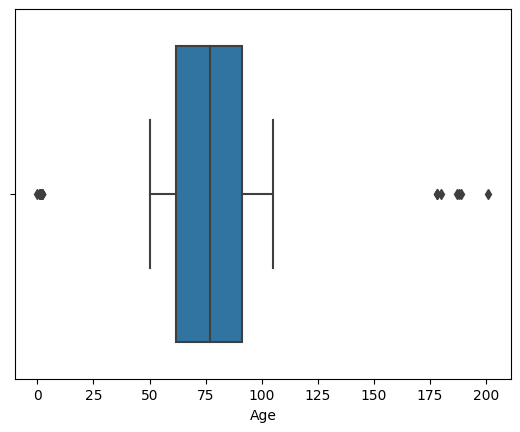

In [49]:
import seaborn as sns
sns.boxplot(df["Age"])

In [50]:
# we need to tranform and treat our data ~ we need to replace these high extreme value with adjusted value now how to find this
# adjusted value

# Upper_level_adjusted_value = Q3 + 1.5* IQR
# lower_level_adjsuted_value = Q1 - 1.5*IQR

In [51]:
df["Age"].describe()

count    518.000000
mean      76.631274
std       23.369315
min        0.000000
25%       62.000000
50%       77.000000
75%       91.000000
max      201.000000
Name: Age, dtype: float64

In [52]:
Q3 = 91
Q1 = 63
IQR = Q3-Q1
IQR

28

In [53]:
upper_value = Q3 + 1.5*IQR
upper_value

133.0

In [54]:
lower_value = Q1- 1.5*IQR
lower_value

21.0

In [55]:
# replace
df["Age_new_replace"] = np.where(df["Age"]>upper_value,upper_value, df["Age"])

In [56]:
df[df["Age"]>120]

,Age,Age_new_replace
499,180,133.0
500,201,133.0
501,189,133.0
502,187,133.0
503,188,133.0
504,178,133.0
505,178,133.0


In [57]:
df["Age_new_replace"] = np.where(df["Age"]<lower_value,lower_value, df["Age_new_replace"])
df[df["Age"]<20]

,Age,Age_new_replace
506,1,21.0
507,2,21.0
508,0,21.0
509,2,21.0
510,2,21.0
511,2,21.0
512,2,21.0
513,1,21.0
514,1,21.0
515,1,21.0


C:\Users\Lenovo\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot: xlabel='Age_new_replace'>

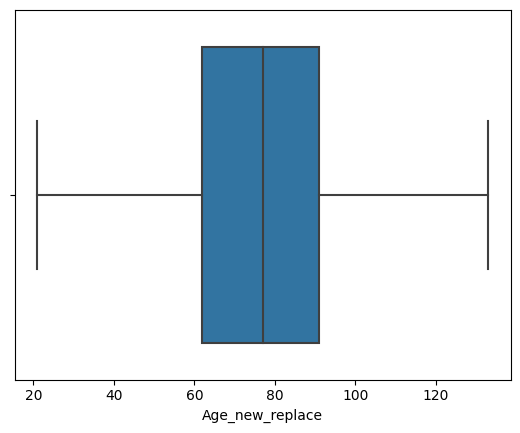

In [58]:
sns.boxplot(df["Age_new_replace"])

C:\Users\Lenovo\anaconda3\lib\site-packages\seaborn\distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot: xlabel='Age', ylabel='Density'>

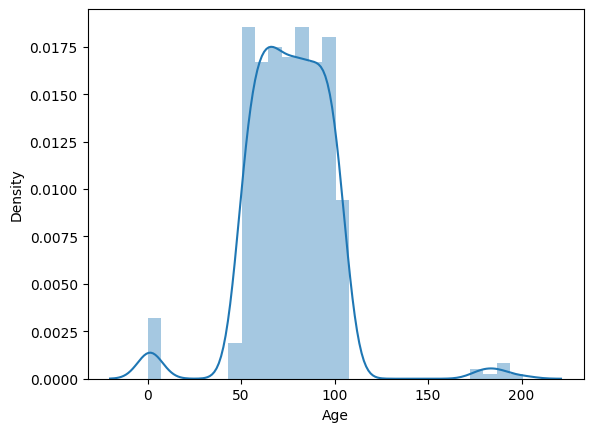

In [60]:
# distribution
sns.distplot(df["Age"])

C:\Users\Lenovo\anaconda3\lib\site-packages\seaborn\distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot: xlabel='Age_new_replace', ylabel='Density'>

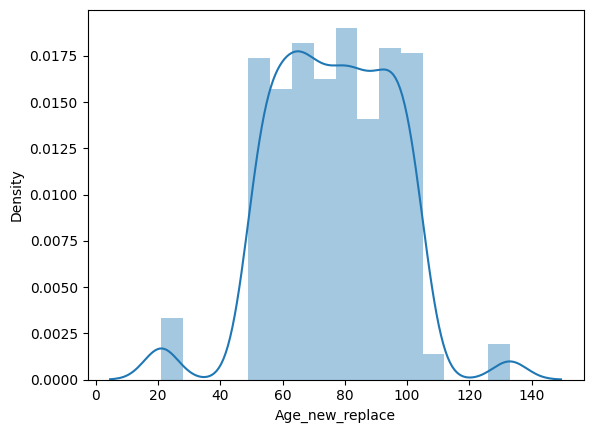

In [61]:
sns.distplot(df["Age_new_replace"])

# Normal Distribution 
- Properties of ND
- 3 sigma rule
- standard normal distribution (Z - distribution)
- Z-value

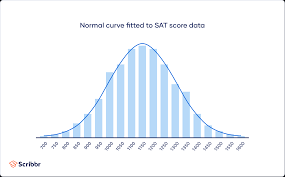

- Normal Dist the data has mean =Mode =Median

C:\Users\Lenovo\anaconda3\lib\site-packages\seaborn\distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot: xlabel='Age', ylabel='Density'>

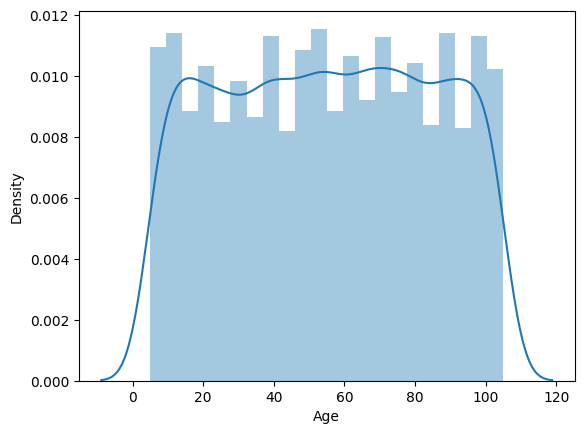

In [63]:
df = pd.DataFrame({"Age":[random.randint(5,105) for i in range(1,10000)]})
sns.distplot(df["Age"])

In [65]:
df["Age"].sample(30).mean()

54.96666666666667

In [88]:
# sample from this : sample size ; 30
# sample : 1000
# 1 batch - 30 peple
sample_list = []
for i in range(1,1001):
    sample_list.append(round(df["Age"].sample(30).mean(),2))
sample_df = pd.DataFrame()
sample_df["sample_age"] = sample_list
sample_df

,sample_age
0,64.20
1,57.53
2,51.00
3,59.80
4,60.03
...,...
995,52.33
996,62.83
997,45.83
998,46.00


C:\Users\Lenovo\anaconda3\lib\site-packages\seaborn\distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot: xlabel='sample_age', ylabel='Density'>

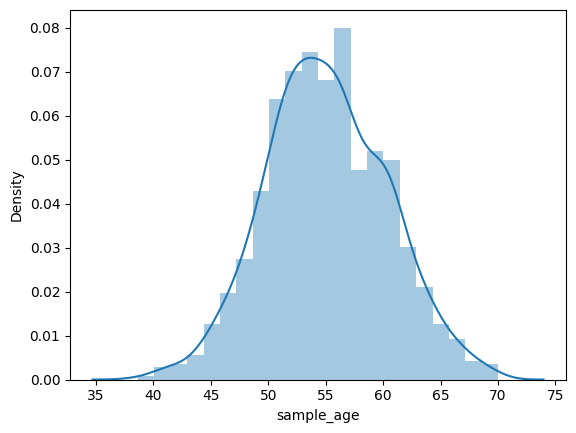

In [89]:
sns.distplot(sample_df["sample_age"])

In [90]:
print(sample_df["sample_age"].mean(),sample_df["sample_age"].median(),sample_df["sample_age"].mode())

55.08117 54.8 0    54.57
Name: sample_age, dtype: float64


In [91]:
# lets find Std, mean for this normal dist
sample_df["sample_age"].mean()

55.08117

In [92]:
sample_df["sample_age"].std()
#ddof - parameter in std() if ddof = 0 then pop
# ddof = 1 sample

5.262091498447935

# Standard Normal / Z-Distribution
- in standard normal dist the dist is same in structure like normal but the mean of dist is zero and std is 1
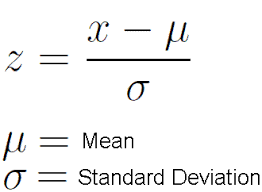

In [95]:
sample_df["Age -  Mean"] = (sample_df["sample_age"] -  sample_df["sample_age"].mean())
sample_df["mean"] = sample_df["sample_age"].mean()
sample_df["STD"] = sample_df["sample_age"].std()
sample_df["Age-mean_age / Std of age"] = sample_df["Age -  Mean"]/sample_df["sample_age"].std()
sample_df["Zvalue_age"] = (sample_df["sample_age"] -  sample_df["sample_age"].mean())/ sample_df["sample_age"].std()
sample_df

,sample_age,Age - Mean,Age-mean_age / Std of age,Zvalue_age,mean,STD
0,64.20,9.11883,1.732929,1.732929,55.08117,5.262091
1,57.53,2.44883,0.465372,0.465372,55.08117,5.262091
2,51.00,-4.08117,-0.775579,-0.775579,55.08117,5.262091
3,59.80,4.71883,0.896759,0.896759,55.08117,5.262091
4,60.03,4.94883,0.940468,0.940468,55.08117,5.262091
...,...,...,...,...,...,...
995,52.33,-2.75117,-0.522828,-0.522828,55.08117,5.262091
996,62.83,7.74883,1.472576,1.472576,55.08117,5.262091
997,45.83,-9.25117,-1.758079,-1.758079,55.08117,5.262091
998,46.00,-9.08117,-1.725772,-1.725772,55.08117,5.262091


C:\Users\Lenovo\anaconda3\lib\site-packages\seaborn\distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot: xlabel='Zvalue_age', ylabel='Density'>

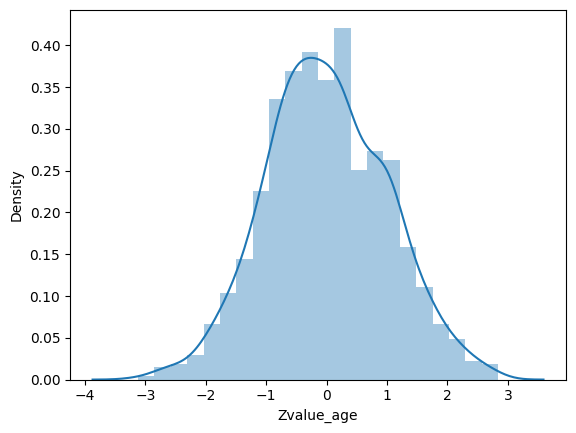

In [96]:
sns.distplot(sample_df["Zvalue_age"])

In [97]:
print("STD",sample_df["Zvalue_age"].std(), "mean",sample_df["Zvalue_age"].mean())

STD 0.9999999999999998 mean -2.3092638912203255e-17


In [98]:
# STD ~=  1 & mean ~=0

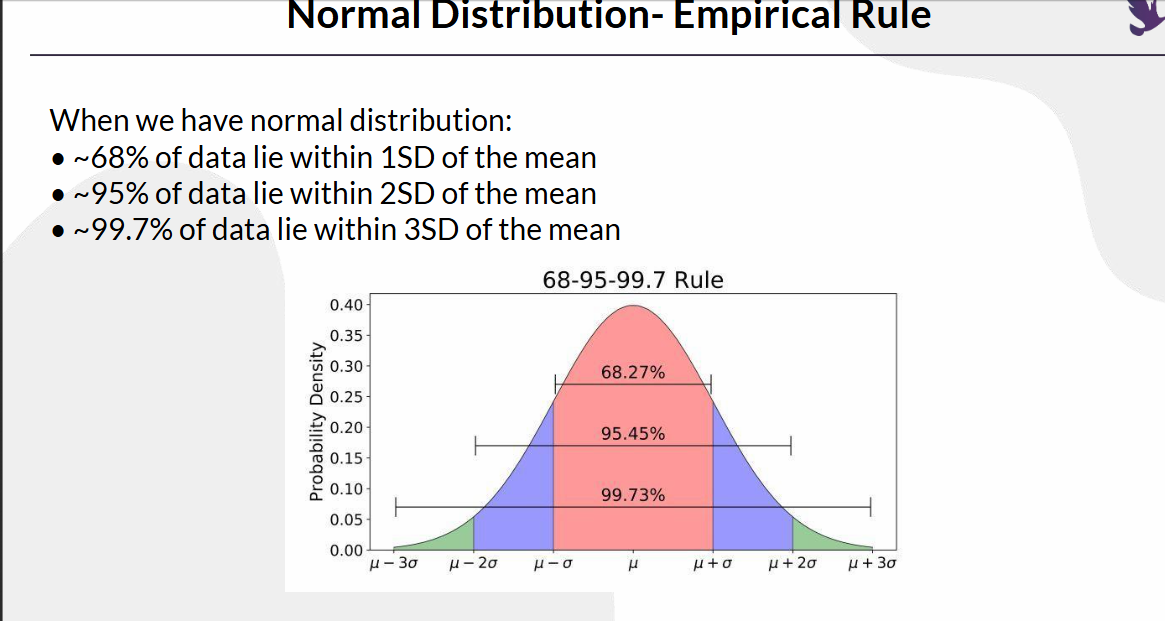

In [99]:
sample_df.head()

,sample_age,Age - Mean,Age-mean_age / Std of age,Zvalue_age,mean,STD
0,64.20,9.11883,1.732929,1.732929,55.08117,5.262091
1,57.53,2.44883,0.465372,0.465372,55.08117,5.262091
2,51.00,-4.08117,-0.775579,-0.775579,55.08117,5.262091
3,59.80,4.71883,0.896759,0.896759,55.08117,5.262091
4,60.03,4.94883,0.940468,0.940468,55.08117,5.262091


In [100]:
# sample_age : tell me how much population we will cover till age 68year

In [102]:
sample_df["sample_age"]

70.0

In [108]:
X = 62
Z_value = (X-  sample_df["sample_age"].mean()) / sample_df["sample_age"].std()
Z_value
# 1.31
# 1.3 + 0.01

1.314844107526584

In [109]:
# look at Z-table and find out the population dist - 90.49% of pop if we have age = 62

In [110]:
X = 68
Z_value = (X-  sample_df["sample_age"].mean()) / sample_df["sample_age"].std()
Z_value
# 1.31
# 1.3 + 0.01

2.4550751357726175

In [ ]:
# look at Z-table and find out the population dist - 99.27% of pop if we have age = 68

In [111]:
# pop ~ 80%
X = 58
Z_value = (X-  sample_df["sample_age"].mean()) / sample_df["sample_age"].std()
Z_value
# base on this we cover 70.8%

0.554690088695895

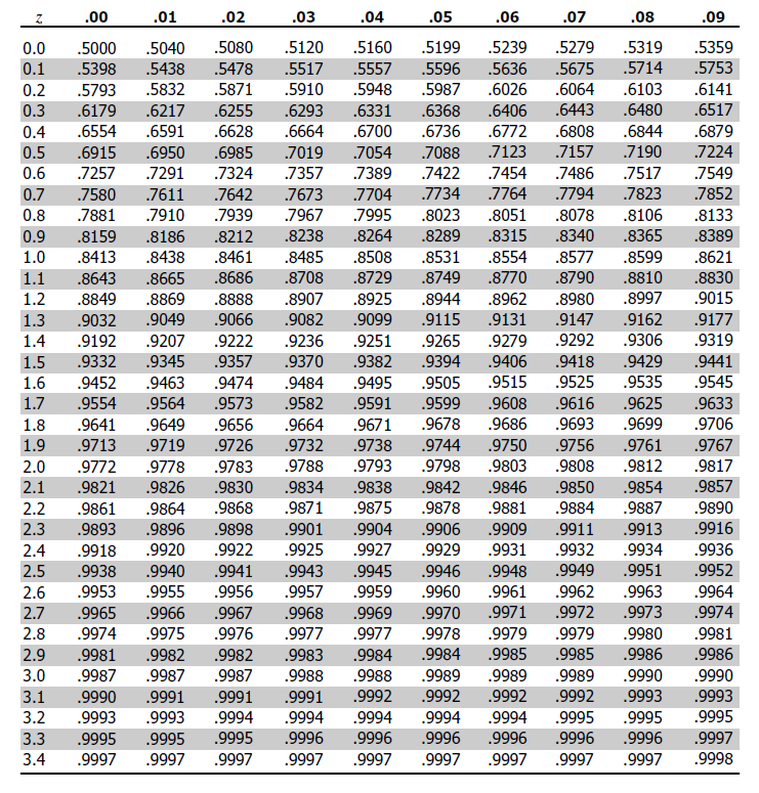

# Inferential Stats
- Hypothesis testing
- T-test (dependent /independent)
- Z- test
- Anova
- Chi square test
- Correlation

# correlation 
- help you to estimate the relationship between two numerical feature
- the range of correlation lies between -1 to 1
- -1 to 0 : Negative correlation
- 0: no correlation
- 0 - +1 : positive correlation

# Correlation are two types
- Pearson correlation - parametric approach (it has some assumption to apply before we use this)
- spearman rank correlation - non-parametric approch(No assumption to full fill)

# Dependent & Independent Variable
- suppose you need to puchase a house 
- house price dependent on area, location, floor number, bedroom ect
- House price is my dependent & other feature are independent

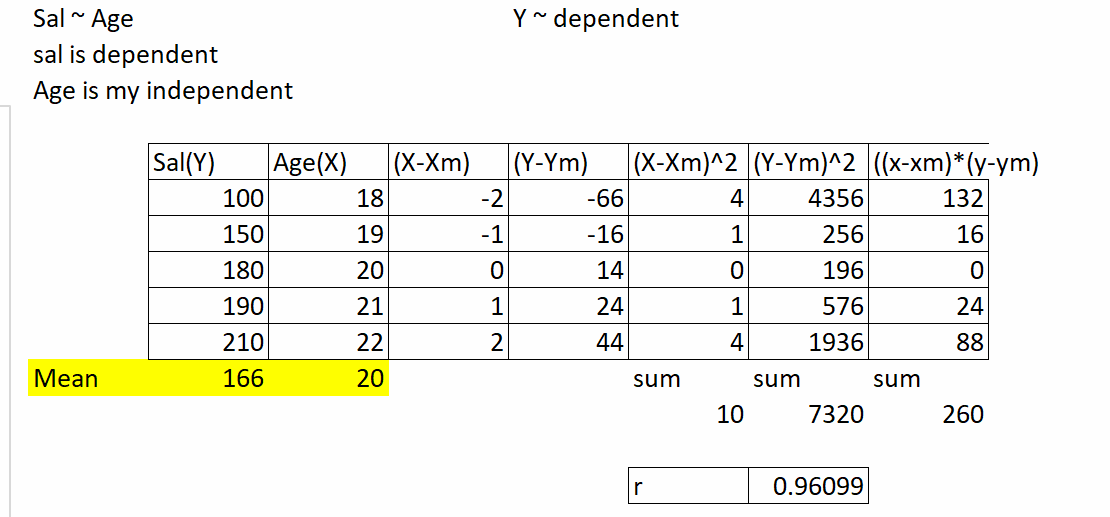

In [112]:
df = pd.DataFrame({"sal":[100,150,180,190,210],
                  "age":[18,19,20,21,22]})
df.head()

,sal,age
0,100,18
1,150,19
2,180,20
3,190,21
4,210,22


In [ ]:
df.corr()
# parametric : pearson - sensitive to outlier
# non parametric : spearman

In [113]:
df.corr(method='pearson')
# parametric : pearson - sensitive to outlier
# non parametric : spearman

,sal,age
sal,1.000000,0.960988
age,0.960988,1.000000


In [ ]:
Obersvation 

In [122]:
df.corr(method='spearman')
# parametric : pearson - sensitive to outlier
# non parametric : spearman

,sal,age
sal,1.0,-0.1
age,-0.1,1.0


In [121]:
df = pd.DataFrame({"sal":[100,150,180,190,210],
                  "age":[2,1.1,100,1456,-123]})
df.corr()

,sal,age
sal,1.000000,0.273337
age,0.273337,1.000000


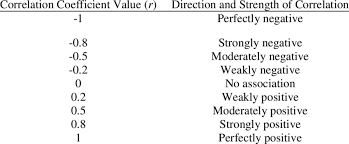


# Hypothesis In Inferential Stats

- Null Hypothesis (No Change) its is denoted by Ho
- Alternate Hypothesis (There is a Change it is denoted by Ha

# Covidshield Case Study
- statement :: using our vaccine your covid condition will improve

# Government Role 
- they started validating the company statement

- define Hypothesis
- Ho: using our vaccine your covid condition no improvement
- Ha: using our vaccine your covid condition will improve

- create two sample group from population (covid people)
- 30 people / 30 people

# to prove which hypothesis is correct we have below
- Z-test ( when you have two group numerical)
- T-test ( two group numerical )
- Anova ( more than two groups) - analysis of variance(numerical)
- chi-square - used between two categorical group

# which test to apply?

In [124]:
from scipy import stats
#print(dir(stats))

In [90]:
from scipy.stats import  ttest_ind,ttest_rel

In [130]:
paired_t_test = pd.read_excel(r"C:\Users\Lenovo\OneDrive\Documents\ds43.xlsx", sheet_name='data t-test paired')
paired_t_test = paired_t_test[['Batch 1(X)', 'Btach 2 (X)']]
paired_t_test.head()

,Batch 1(X),Btach 2 (X)
0,64.0,62.0
1,80.0,85.0
2,63.0,67.0
3,55.0,88.0
4,58.0,75.0


## define Hypothesis
- H0: Mean or Avg mark of batch 1 == Mean or Avg mark of batch 2
- Ha: Mean or Avg mark of batch 1 <> Mean or Avg mark of batch 2

In [131]:
print(ttest_rel(a=paired_t_test['Batch 1(X)'], b = paired_t_test['Btach 2 (X)']))

Ttest_relResult(statistic=0.5605518754447949, pvalue=0.5766131040587463)


# Result Interpreation
- Confidence Interval - 95% making a error is 5%
- you work in a manufacting company: company make iron bolts: out 100 new bolt 5 are damage while testing - confidence - 95%chance of making error - 5%
- Confidence Interval 
- Signifcant value (Psignificant value) it is calculated as 1-CI(confidence Interval)
#### For General Case we consider CI - 95% which means Significant_value_P_significant 1-95%  = 5% ~ 0.05

##### Rule when to accept Null hypothesis and when to reject 
- when P_value_calculated_from_test > Significant_value_P_significant - H0 is True 
- when P_value_calculated_from_test < Significant_value_P_significant - HA is True 

In [134]:
pvalue=0.5766131040587463
if pvalue>0.05:
    print("H0 is accepted- H0: Mean or Avg mark of batch 1 == Mean or Avg mark of batch 2")
else:
    print("H0 is rejected Ha: Mean or Avg mark of batch 1 <> Mean or Avg mark of batch 2")
print("Change of method will not change mark of student")

H0 is accepted- H0: Mean or Avg mark of batch 1 == Mean or Avg mark of batch 2
Change of method will not change mark of student


In [137]:
unpaired_t_test = pd.read_excel(r"C:\Users\Lenovo\OneDrive\Documents\ds43.xlsx", sheet_name="data t test unpaired")
unpaired_t_test = unpaired_t_test[['Credit Card' ,'Unnamed: 1']]
unpaired_t_test = unpaired_t_test.iloc[2:,]
unpaired_t_test.head()

,Credit Card,Unnamed: 1
2,73,female
3,23,male
4,53,male
5,20,male
6,41,female


In [142]:
male = unpaired_t_test[unpaired_t_test['Unnamed: 1']=='male']['Credit Card']
female = unpaired_t_test[unpaired_t_test['Unnamed: 1']=='female']['Credit Card']

2     73
6     41
8     78
9     61
11    39
12    78
15    53
Name: Credit Card, dtype: object

In [144]:
print(ttest_ind(a=male,b=female))

Ttest_indResult(statistic=-2.8641103859112036, pvalue=0.014244719138018147)


In [ ]:
H0: female card == male card usage
Ha:  female card <> male card usage
BAsed on Test-pvalue =0.0142
testpvalue < Psign 
0.0142 < 0.05
Yes
Ha:  female card <> male card usage -  correct
Campagin was success - we lauch it for female category

statement - You have two company which provide data science course to student, we need to which company has most selection by month in different company. both company agree to provide the data and we found that the mean is X value they also proivde std of population , and in sample the size is 40? 

<br>
<br>
Z-test

In [11]:
import random
import numpy as np
from statsmodels.stats.weightstats import ztest
# Example data for two groups
group1_A = np.array([random.randint(20,200) for i in  range(1,51)])
group2_B = np.array([random.randint(20,200) for i in range(1,51)])
print(group1_A.mean(), group2_B.mean())
print(group1_A.std(), group2_B.std())

114.42 111.66
52.56390015971038 53.87675194367233


when I look at the mean the value was very differnt just based on my avg I can say two statement<br>
- H0: Avg selection of company A = Avg selection of company B
- Ha: Avg selection of company A <> Avg selection of company B

In [12]:
# Perform Z-test
z_stat, p_value = ztest(group1_A, group2_B)
print('Z-statistic:', z_stat)
print('p-value:', p_value)

Z-statistic: 0.2566738123185111
p-value: 0.7974305891499791


In [13]:
# as for this case we consider CI = 99% P_sig_mistake = 1-99% ~ 1-0.99 ~ 0.01
p_sig = 0.01
if p_value<p_sig:
    print("Ha is accepted")
    if group1_A.mean()> group2_B.mean():
        print("company A is best and have more selection")
    else:
        print("company B is best and have more selection") 
else:
    print("Ho is accepted")

Ho is accepted


- Now we have a problem where we run a campiagn to understand the discount on alchol we conducted the demand in 3 region now we need to know is the mean demand in all region is same or its different?

- ANOVA: Analysis of variance ( when you have more than 2 groups)
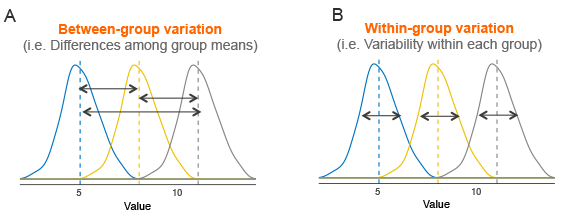


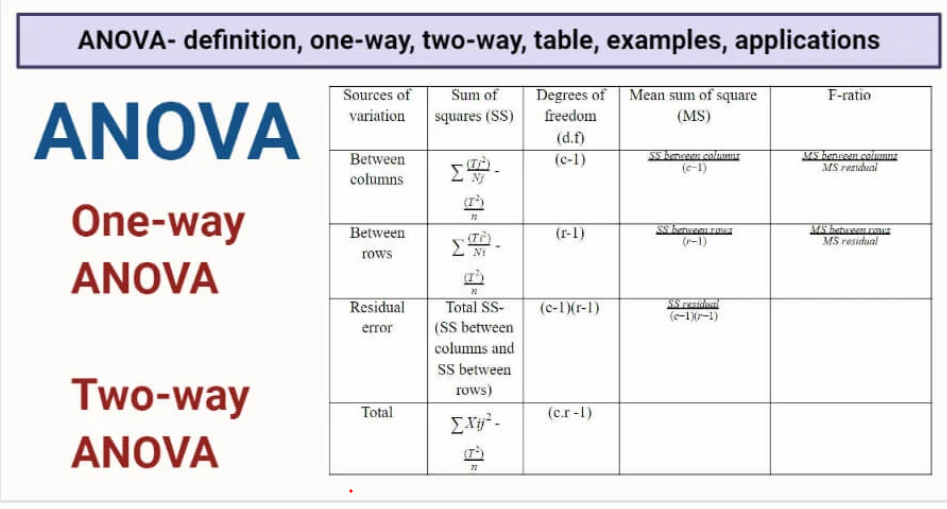

In [14]:
from scipy.stats import f_oneway
# CI = 90% Psig = 1-.90 ~ 0.10
# P_sig = 0.10

group1_A = np.array([random.randint(20,200) for i in  range(1,51)])
group2_B = np.array([random.randint(20,200) for i in range(1,51)])
group3_C = np.array([random.randint(20,200) for i in range(1,51)])

# Perform ANOVA
F, p = f_oneway(group1_A, group2_B, group3_C)

print('F-statistic:', F)
print('p-value:', p)


F-statistic: 1.1324554541806304
p-value: 0.32503582972403705


# Error - Mistake 
- Type 1 error 
- type 2 error

- Experiment: you created a drug to treat cancer
- Ho: No effect of drug
- Ha: effect of drug on cancer

case when when the drug was creating impact but you accepted null hypo ~ type 1..

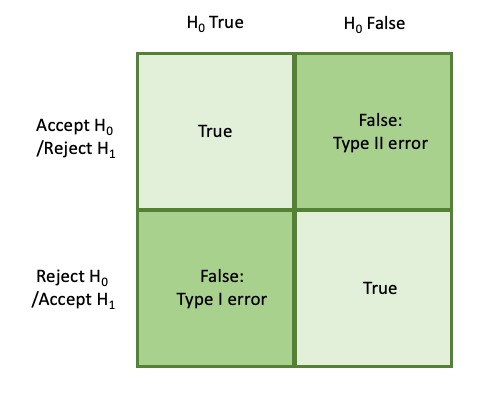

In [ ]:
We conduted a test where we use vitamin to boost imunity
group A - Vitamin
group B - No vitamin

H0: No impact of vitamin
Ha: Group which has vitamin there is x% of immunity uplift
    
# case 1 when there was no impact of vitamin - correct case H0
# your selection or you selcted Ha: mistake (type 1 error)


# case 2 when there was impact of vitamin - correct case Ha
# your selection or you selcted Ho: mistake (type 2 error)

# Chi - Sqaure 
- you might seen correlation analysis for Numerical variable ~ Pearson/speraman rank same when you need to find relationship between categorical data always refer CHI-SQUARE Test
- When you have two categorical / more than two categorical values
- You are doing a machine project where you need to know whether gender is correlated with skill(home work/ cartep/labour)

In [25]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
# CI ~ 90% P_sig = 1-CI ~ 0.10
df = pd.DataFrame({'Category1':['M','M','M','F','F'],
                  'Category2':['G','PG','PHD','G','PHD']})
# Create contingency table
contingency_table = pd.crosstab(df['Category1'], df['Category2'])
print('Contingency Table:')
print(contingency_table)
# Perform Chi-Square test
result = chi2_contingency(contingency_table)
result

Contingency Table:
Category2  G  PG  PHD
Category1            
F          1   0    1
M          1   1    1


(0.8333333333333334,
 0.6592406302004438,
 2,
 array([[0.8, 0.4, 0.8],
        [1.2, 0.6, 1.2]]))

In [22]:
# P value test = 0.6592
# P value test < Psig ~ Accept Null
# pvalue test > psig ~ reject alternate
H0 is accepted : there is no relationship or both group gender and education are significant same (and we cannot judge education base on two feature)

(14.0,
 0.3007082761743609,
 12,
 array([[0.44444444, 0.44444444, 1.33333333, 1.33333333, 0.44444444],
        [0.33333333, 0.33333333, 1.        , 1.        , 0.33333333],
        [0.11111111, 0.11111111, 0.33333333, 0.33333333, 0.11111111],
        [0.11111111, 0.11111111, 0.33333333, 0.33333333, 0.11111111]]))

In [24]:
P_value = result[1]
P_value
# CI - 95% / P - 1-0.95 ~ 0.05
# H0/Ha 
#Ho: both group are same 
# Ha: both groups are different
# final statement ~ H0 is accpeted

0.3007082761743609

# EDA & Stats
- when you perform analysis you take data based on casestudy you comes with some suggestion or insight
- What is Exploratory Data Analysis ?<br>
Exploratory Data Analysis or (EDA) is understanding the data sets by summarizing their main characteristics often plotting them visually. This step is very important especially when we arrive at modeling the data in order to apply Machine learning. Plotting in EDA consists of Histograms, Box plot, Scatter plot and many more. It often takes much time to explore the data. Through the process of EDA, we can ask to define the problem statement or definition on our data set which is very important.

### Titanic
- you are working as an analyst in White star line and your boss need to understand some insight fom the disaster
- data ~ source (Kaggle/sns module)

In [150]:
import seaborn as sns
import matplotlib.pyplot as plt
#print(dir(sns))
from seaborn import load_dataset
import seaborn as sns
data = load_dataset('titanic')

In [151]:
?load_dataset

In [153]:
data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


# EDA Question 
- what is the shape of data
- what each column data variable
- any missing in data
- unique value of each categorucal column
- stats sumamry of each columns

In [154]:
#what is the shape of data
data.shape

(891, 15)

In [155]:
# what each column data variable
data.dtypes

survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object

In [156]:
# missing point
data.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [157]:
# missing point %
data.isnull().sum()/ len(data)

survived       0.000000
pclass         0.000000
sex            0.000000
age            0.198653
sibsp          0.000000
parch          0.000000
fare           0.000000
embarked       0.002245
class          0.000000
who            0.000000
adult_male     0.000000
deck           0.772166
embark_town    0.002245
alive          0.000000
alone          0.000000
dtype: float64

In [158]:
data.head(2)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False


In [159]:
data["pclass"].unique()

array([3, 1, 2], dtype=int64)

In [160]:
# how many passenger belong to class - 1
data["pclass"].value_counts()

3    491
1    216
2    184
Name: pclass, dtype: int64

In [161]:
data.groupby(['pclass']).agg({"sibsp":"count"})

,sibsp
pclass,
1,216
2,184
3,491


In [162]:
# stats summary numerical columns 
data.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [163]:
# question EDA part - How many passenger in each class - died/lived
dd = data.reset_index()
dd.head()

,index,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [164]:
dd.groupby(['pclass','sex']).agg({"index":"count"}).reset_index().rename(columns={"index":"gender count"})
# EDA analysis - Most chances of survival is for 1st class passenger
# most low chance was for 3rd class passenger

,pclass,sex,gender count
0,1,female,94
1,1,male,122
2,2,female,76
3,2,male,108
4,3,female,144
5,3,male,347


In [55]:
dd.groupby(['survived','pclass']).agg({"index":"count"}).reset_index().rename(columns={"index":"passenger_count"})
# EDA analysis - Most chances of survival is for 1st class passenger
# most low chance was for 3rd class passenger

,survived,pclass,passenger_count
0,0,1,80
1,0,2,97
2,0,3,372
3,1,1,136
4,1,2,87
5,1,3,119


In [58]:
# what is the total money we make from each port by selling ticket
# fair- sum by port
em_fare = dd.groupby(['embark_town']).agg({"fare":"sum"}).reset_index()
em_fare

,embark_town,fare
0,Cherbourg,10072.2962
1,Queenstown,1022.2543
2,Southampton,17439.3988


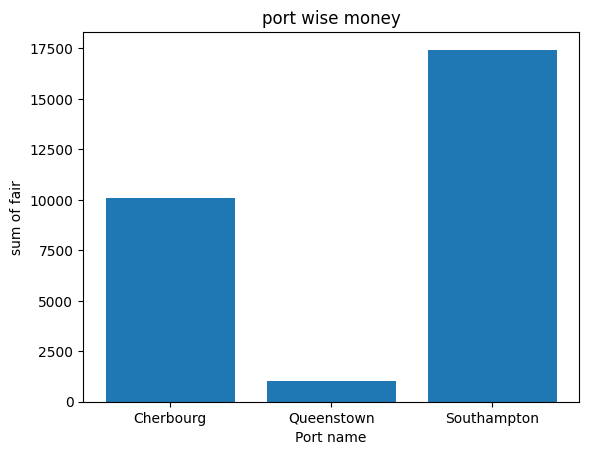

In [62]:
# bar chart
import matplotlib.pyplot as plt
plt.bar(em_fare['embark_town'],em_fare['fare'])
plt.title('port wise money')
plt.xlabel('Port name')
plt.ylabel('sum of fair')
plt.show()

# stats test
- Age have any significant relationship with survival
- two group (A) ~ died (B)- lived 


In [64]:
data.isnull().sum()/len(data)

survived       0.000000
pclass         0.000000
sex            0.000000
age            0.198653
sibsp          0.000000
parch          0.000000
fare           0.000000
embarked       0.002245
class          0.000000
who            0.000000
adult_male     0.000000
deck           0.772166
embark_town    0.002245
alive          0.000000
alone          0.000000
dtype: float64

- If a column have missing data more than 55-65% remove that columns becoz you cannot fill the value
### how to deal with missing value - numerical
- using stats central tendency method
- impuation (strategy)

C:\Users\Lenovo\anaconda3\lib\site-packages\seaborn\distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot: xlabel='age', ylabel='Density'>

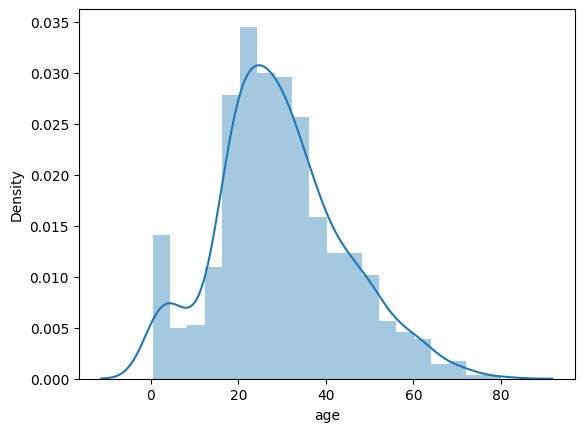

In [65]:
sns.distplot(data['age'])

In [66]:
# when data is having missing you can have ways to fill
# m1: use a constant alue to fill all missing 
# m2: use stats value(mean/mode/median)
# m3: connect to get best value

In [67]:
# use dist to check - normal/ skew
# when data is normal use any - mean/median/mode
# skew ~ median

In [76]:
mv = data.copy()
mv.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [77]:
mv['age']= mv['age'].astype(float)

In [78]:
values = mv['age'].median()
mv['age'].fillna(value=values)
mv.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [79]:
#mv['age'] = mv['age'].fillna(value=values)
mv['age'].fillna(value=values,inplace=True)
mv.isnull().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [82]:
age_sur = mv[mv['survived']==1][['age']]
age_non_sur = mv[mv['survived']==0][['age']]
print(age_sur.shape, age_non_sur.shape)

(342, 1) (549, 1)


In [87]:
# sample size 25
# each batch - 10 batches
age_sur_sample = []
age_notsur_sample = []
for i in range(1,10):
    age_sur_sample.append(age_sur['age'].sample(25).mean())
for i in range(1,10):
    age_notsur_sample.append(age_non_sur['age'].sample(25).mean())

age_sur_sample

[28.8,
 22.983199999999997,
 26.396800000000002,
 27.28,
 31.9,
 29.96,
 24.2136,
 31.45,
 26.69]

In [88]:
age_notsur_sample

[27.36, 31.58, 28.52, 32.06, 33.0, 32.3, 26.24, 28.92, 30.04]

In [91]:
from scipy.stats import  ttest_ind,ttest_rel
print(ttest_ind(a=age_sur_sample,b=age_notsur_sample))
# each case we consider some CI (infer test) for this case by defult we use CI = 95%
# CI ~ 95% Psig - 5%~ 0.05

Ttest_indResult(statistic=-1.7453444505488342, pvalue=0.10009624772672132)


In [ ]:
# Age has no siginficant impact on survival

# Categorical value missing

In [93]:
df = pd.DataFrame({"T1":[np.nan,'B','C',np.nan,'Y','Y','Y']})
df

,T1
0,NaN
1,B
2,C
3,NaN
4,Y
5,Y
6,Y


In [94]:
# 3 ways 
#m1 : to fill wiht mode value
# m2: with backfill
# m3: ffill method

In [101]:
df1 = df.copy()
df1['T1'].mode().values[0]

'Y'

In [102]:
df1['T1'].fillna(df1['T1'].mode().values[0],inplace=True)
df1

,T1
0,Y
1,B
2,C
3,Y
4,Y
5,Y
6,Y


In [106]:
df1 = df.copy()
df1

,T1
0,NaN
1,B
2,C
3,NaN
4,Y
5,Y
6,Y


In [107]:

df1['T1'].fillna(method='bfill',inplace=True)
df1

,T1
0,B
1,B
2,C
3,Y
4,Y
5,Y
6,Y


In [108]:
df1 = df.copy()
df1

,T1
0,NaN
1,B
2,C
3,NaN
4,Y
5,Y
6,Y


In [109]:
df1['T1'].fillna(method='ffill',inplace=True)
df1

,T1
0,NaN
1,B
2,C
3,C
4,Y
5,Y
6,Y


In [110]:
df = pd.DataFrame({"T1":[np.nan,'B','C',np.nan,'Y','Y',np.nan]})
df

,T1
0,NaN
1,B
2,C
3,NaN
4,Y
5,Y
6,NaN


In [111]:
df['T1'].fillna(method='ffill',inplace=True)
df

,T1
0,NaN
1,B
2,C
3,C
4,Y
5,Y
6,Y


In [112]:
df['T1'].fillna(method='bfill',inplace=True)
df

,T1
0,B
1,B
2,C
3,C
4,Y
5,Y
6,Y


## Model in machine learning can only handle numerical values 
- Categorical data we need to transform them into numerical data
-  dummy variable
- one-hot encoding
- label encoding

In [117]:
df = pd.DataFrame({"T1":['B','B','C','Y','Y']})
df

,T1
0,B
1,B
2,C
3,Y
4,Y


In [118]:
# m1 : label encoding
from sklearn.preprocessing import LabelEncoder
variable_labelecoder = LabelEncoder()
df['T1_labelencoder'] = variable_labelecoder.fit_transform(df['T1'])
df

,T1,T1_labelencoder
0,B,0
1,B,0
2,C,1
3,Y,2
4,Y,2


In [121]:
# m2: dummy variable
# dummy rule: when creating dummy variable use N-1 feature row as columns
dm = pd.get_dummies(df['T1'])
dm

,B,C,Y
0,1,0,0
1,1,0,0
2,0,1,0
3,0,0,1
4,0,0,1


In [123]:
net_df = pd.concat([df,dm[['B','C']]],axis=1)
net_df

,T1,T1_labelencoder,B,C
0,B,0,1,0
1,B,0,1,0
2,C,1,0,1
3,Y,2,0,0
4,Y,2,0,0


In [127]:
from sklearn.preprocessing import  OneHotEncoder
OHE = OneHotEncoder()

In [130]:
var = OHE.fit_transform(net_df[['T1']])
var.toarray()

array([[1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 0., 1.]])

In [132]:
OHE.categories_

[array(['B', 'C', 'Y'], dtype=object)]

In [134]:
ohe_df = pd.DataFrame(data=var.toarray(), columns=OHE.categories_)
ohe_df

,B,C,Y
0,1.0,0.0,0.0
1,1.0,0.0,0.0
2,0.0,1.0,0.0
3,0.0,0.0,1.0
4,0.0,0.0,1.0


# how to handle date time variable

In [135]:
df = pd.read_excel(r'C:\Users\Lenovo\OneDrive\Desktop\data.xlsx')
df.head()

,Date
0,2021-01-01
1,2017-02-05
2,2024-10-18
3,2019-05-17


In [136]:
df.dtypes

Date    datetime64[ns]
dtype: object

In [137]:
df["stringfromat"] = df['Date'].astype(str)
df.dtypes

Date            datetime64[ns]
stringfromat            object
dtype: object

In [138]:
df

,Date,stringfromat
0,2021-01-01,2021-01-01
1,2017-02-05,2017-02-05
2,2024-10-18,2024-10-18
3,2019-05-17,2019-05-17


In [139]:
df["stringfromat_dateformat"] = pd.to_datetime(df['stringfromat'])
df

,Date,stringfromat,stringfromat_dateformat
0,2021-01-01,2021-01-01,2021-01-01
1,2017-02-05,2017-02-05,2017-02-05
2,2024-10-18,2024-10-18,2024-10-18
3,2019-05-17,2019-05-17,2019-05-17


In [140]:
df.dtypes

Date                       datetime64[ns]
stringfromat                       object
stringfromat_dateformat    datetime64[ns]
dtype: object

In [142]:
# so you can use datetime method to break date into : month, year, week, yearweek, month,name..
df['Year'] = df['Date'].dt.year
df

,Date,stringfromat,stringfromat_dateformat,Year
0,2021-01-01,2021-01-01,2021-01-01,2021
1,2017-02-05,2017-02-05,2017-02-05,2017
2,2024-10-18,2024-10-18,2024-10-18,2024
3,2019-05-17,2019-05-17,2019-05-17,2019


In [143]:
# so you can use datetime method to break date into : month, year, week, yearweek, month,name..
df['Year_month'] = df['Date'].dt.month
df

,Date,stringfromat,stringfromat_dateformat,Year,Year_month
0,2021-01-01,2021-01-01,2021-01-01,2021,1
1,2017-02-05,2017-02-05,2017-02-05,2017,2
2,2024-10-18,2024-10-18,2024-10-18,2024,10
3,2019-05-17,2019-05-17,2019-05-17,2019,5


In [146]:
df['Year_month_name'] = df['Date'].dt.month_name()
df

,Date,stringfromat,stringfromat_dateformat,Year,Year_month,Year_month_name
0,2021-01-01,2021-01-01,2021-01-01,2021,1,January
1,2017-02-05,2017-02-05,2017-02-05,2017,2,February
2,2024-10-18,2024-10-18,2024-10-18,2024,10,October
3,2019-05-17,2019-05-17,2019-05-17,2019,5,May


In [147]:
df['week'] = df['Date'].dt.week
df

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_4704\2827552329.py:1: FutureWarning: Series.dt.weekofyear and Series.dt.week have been deprecated. Please use Series.dt.isocalendar().week instead.
  df['week'] = df['Date'].dt.week


,Date,stringfromat,stringfromat_dateformat,Year,Year_month,Year_month_name,week
0,2021-01-01,2021-01-01,2021-01-01,2021,1,January,53
1,2017-02-05,2017-02-05,2017-02-05,2017,2,February,5
2,2024-10-18,2024-10-18,2024-10-18,2024,10,October,42
3,2019-05-17,2019-05-17,2019-05-17,2019,5,May,20


In [148]:
df['day'] = df['Date'].dt.day
df

,Date,stringfromat,stringfromat_dateformat,Year,Year_month,Year_month_name,week,day
0,2021-01-01,2021-01-01,2021-01-01,2021,1,January,53,1
1,2017-02-05,2017-02-05,2017-02-05,2017,2,February,5,5
2,2024-10-18,2024-10-18,2024-10-18,2024,10,October,42,18
3,2019-05-17,2019-05-17,2019-05-17,2019,5,May,20,17


In [149]:
df['day_name'] = df['Date'].dt.day_name()
df

,Date,stringfromat,stringfromat_dateformat,Year,Year_month,Year_month_name,week,day,day_name
0,2021-01-01,2021-01-01,2021-01-01,2021,1,January,53,1,Friday
1,2017-02-05,2017-02-05,2017-02-05,2017,2,February,5,5,Sunday
2,2024-10-18,2024-10-18,2024-10-18,2024,10,October,42,18,Friday
3,2019-05-17,2019-05-17,2019-05-17,2019,5,May,20,17,Friday


# Task 

In [ ]:
#Load titanic dataset from seaborn and print head,tail,shape and describe.
#Note: code to load the dataset
import seaborn as sns
titanic=sns.load_dataset("titanic")
print(titanic.head())
print(titanic.tail())
print(titanic.shape())
print(titanic.describe())

## Titanic case study
- We need to create a model which can predict the chance of person in such or similar titanic disaster
- Model which can consider feature of passenger and predict wheather the person will live /die
- data used is historical disaster data


In [83]:
import seaborn as sns
import matplotlib.pyplot as plt
#print(dir(sns))
from seaborn import load_dataset
import seaborn as sns
data = load_dataset('titanic')
data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [84]:
data.pop('deck')
data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


In [85]:
data.drop(['class','embark_town'],axis=1,inplace=True)
data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,who,adult_male,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,man,True,no,False
1,1,1,female,38.0,1,0,71.2833,C,woman,False,yes,False
2,1,3,female,26.0,0,0,7.9250,S,woman,False,yes,True
3,1,1,female,35.0,1,0,53.1000,S,woman,False,yes,False
4,0,3,male,35.0,0,0,8.0500,S,man,True,no,True


In [86]:
data['age'].fillna(data['age'].median(),inplace=True)
data['embarked'].fillna('S',inplace=True)
data.isnull().sum()

survived      0
pclass        0
sex           0
age           0
sibsp         0
parch         0
fare          0
embarked      0
who           0
adult_male    0
alive         0
alone         0
dtype: int64

In [87]:
data.head(3)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,who,adult_male,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,man,True,no,False
1,1,1,female,38.0,1,0,71.2833,C,woman,False,yes,False
2,1,3,female,26.0,0,0,7.9250,S,woman,False,yes,True


In [88]:
cat = data.select_dtypes(include=['object','category','bool']).columns
num = data.select_dtypes(include=['number']).columns

In [90]:
num

Index(['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare'], dtype='object')

In [89]:
cat

Index(['sex', 'embarked', 'who', 'adult_male', 'alive', 'alone'], dtype='object')

In [98]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for i in cat:
    data[i] = le.fit_transform(data[i])
data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,who,adult_male,alive,alone
0,0,3,1,22.0,1,0,7.2500,2,1,1,0,0
1,1,1,0,38.0,1,0,71.2833,0,2,0,1,0
2,1,3,0,26.0,0,0,7.9250,2,2,0,1,1
3,1,1,0,35.0,1,0,53.1000,2,2,0,1,0
4,0,3,1,35.0,0,0,8.0500,2,1,1,0,1


## problme statement : to predict the person survival 
- Survived column - target variable(dependent variable)
- other columns will be my independent variable

# Understand how to select best feature for you model
- Correlation between independent feature and reomove feature which are correlated (indepndent) this process is called as process of multicollineatiy check
- Correlation analysis
- model based feature selection

#### Multicolinearity
- when independent feature are high corelated it can bias the output result this has to be treated (method fore treatment - VIF)
- VIF is onlt appiled on independent data
- vif is a python module
- variance inflation factor
- any indep feature having multi colinearity >10 is not consider

In [111]:
data.head(2)
X = data.drop(['survived'],axis=1)
Y = data[['survived']]

In [112]:
X.head(2)

,pclass,sex,age,sibsp,parch,fare,embarked,who,adult_male,alive,alone
0,3,1,22.0,1,0,7.2500,2,1,1,0,0
1,1,0,38.0,1,0,71.2833,0,2,0,1,0


In [113]:
Y.head(2)

,survived
0,0
1,1


In [117]:
# new feature 
X['total member'] = X['sibsp']+X['parch']
X.head()

,pclass,sex,age,sibsp,parch,fare,embarked,who,adult_male,alive,alone,total member
0,3,1,22.0,1,0,7.2500,2,1,1,0,0,1
1,1,0,38.0,1,0,71.2833,0,2,0,1,0,1
2,3,0,26.0,0,0,7.9250,2,2,0,1,1,0
3,1,0,35.0,1,0,53.1000,2,2,0,1,0,1
4,3,1,35.0,0,0,8.0500,2,1,1,0,1,0


In [122]:
X.drop(['sibsp','parch','alive'],axis=1,inplace=True)
X.head()

,pclass,sex,age,fare,embarked,who,adult_male,alone,total member
0,3,1,22.0,7.2500,2,1,1,0,1
1,1,0,38.0,71.2833,0,2,0,0,1
2,3,0,26.0,7.9250,2,2,0,1,0
3,1,0,35.0,53.1000,2,2,0,0,1
4,3,1,35.0,8.0500,2,1,1,1,0


In [123]:
# correlation (when X,Y are correlated)
net_df = pd.concat([Y,X],axis=1)
net_df.head()

,survived,pclass,sex,age,fare,embarked,who,adult_male,alone,total member
0,0,3,1,22.0,7.2500,2,1,1,0,1
1,1,1,0,38.0,71.2833,0,2,0,0,1
2,1,3,0,26.0,7.9250,2,2,0,1,0
3,1,1,0,35.0,53.1000,2,2,0,0,1
4,0,3,1,35.0,8.0500,2,1,1,1,0


#### In order to predict Y if Y is correlaed with X then only you can have a pattern or relation

In [128]:
net_df.corr()['survived']

survived        1.000000
pclass         -0.338481
sex            -0.543351
age            -0.064910
fare            0.257307
embarked       -0.167675
who             0.325753
adult_male     -0.557080
alone          -0.203367
total member    0.016639
Name: survived, dtype: float64

In [141]:
# any feature indep have vif >10 is not a good feature to consider
from statsmodels.stats.outliers_influence import variance_inflation_factor 
import pandas as pd
# VIF dataframe 
X = net_df.drop(['survived'],axis=1)
vif_data = pd.DataFrame() 
vif_data["feature"] = X.columns 

# calculating VIF for each feature 
vif_data["VIF"] = [variance_inflation_factor(X.values, i) 
						for i in range(len(X.columns))] 
X_new_feature = net_df[[i for i in vif_data[vif_data['VIF']<10]['feature']]]
X_new_feature.head()

,pclass,age,fare,embarked,alone,total member
0,3,22.0,7.2500,2,0,1
1,1,38.0,71.2833,0,0,1
2,3,26.0,7.9250,2,1,0
3,1,35.0,53.1000,2,0,1
4,3,35.0,8.0500,2,1,0


In [142]:
# correlation (when X,Y are correlated)
net_df1 = pd.concat([Y,X],axis=1)
net_df1.head()

,survived,pclass,sex,age,fare,embarked,who,adult_male,alone,total member
0,0,3,1,22.0,7.2500,2,1,1,0,1
1,1,1,0,38.0,71.2833,0,2,0,0,1
2,1,3,0,26.0,7.9250,2,2,0,1,0
3,1,1,0,35.0,53.1000,2,2,0,0,1
4,0,3,1,35.0,8.0500,2,1,1,1,0


In [ ]:
# you can remove the feature which have low correlation with target variable

In [143]:
#correlation 
net_df1.corr()

,survived,pclass,sex,age,fare,embarked,who,adult_male,alone,total member
survived,1.000000,-0.338481,-0.543351,-0.064910,0.257307,-0.167675,0.325753,-0.557080,-0.203367,0.016639
pclass,-0.338481,1.000000,0.131900,-0.339898,-0.549500,0.162098,-0.196793,0.094035,0.135207,0.065997
sex,-0.543351,0.131900,1.000000,0.081163,-0.182333,0.108262,-0.639773,0.908578,0.303646,-0.200988
age,-0.064910,-0.339898,0.081163,1.000000,0.096688,-0.018754,0.350163,0.247704,0.171647,-0.245619
fare,0.257307,-0.549500,-0.182333,0.096688,1.000000,-0.224719,0.146290,-0.182024,-0.271832,0.217138
embarked,-0.167675,0.162098,0.108262,-0.018754,-0.224719,1.000000,-0.064154,0.092526,0.063532,0.066516
who,0.325753,-0.196793,-0.639773,0.350163,0.146290,-0.064154,1.000000,-0.437532,0.006540,-0.120771
adult_male,-0.557080,0.094035,0.908578,0.247704,-0.182024,0.092526,-0.437532,1.000000,0.404744,-0.348143
alone,-0.203367,0.135207,0.303646,0.171647,-0.271832,0.063532,0.006540,0.404744,1.000000,-0.690922
total member,0.016639,0.065997,-0.200988,-0.245619,0.217138,0.066516,-0.120771,-0.348143,-0.690922,1.000000


#### filter feature which are not correlation with Target (cor low)

In [144]:
data.shape

(891, 12)

In [161]:
var1 = net_df1.corr()['survived'].reset_index()
var2 = var1[(var1['survived']>.25) | (var1['survived']<-.25)]
for i in var2['index']:
    print(i)

survived
pclass
sex
fare
who
adult_male


In [162]:
final = data[[i for i in var2['index']]]
final.head()

,survived,pclass,sex,fare,who,adult_male
0,0,3,1,7.2500,1,1
1,1,1,0,71.2833,2,0
2,1,3,0,7.9250,2,0
3,1,1,0,53.1000,2,0
4,0,3,1,8.0500,1,1


# feature scaling
- Scaling is always done on Independent feature do not scale your dependent feature
- MinMax scaling
- standrad sacling

In machine learning, normalization and standardization are two techniques used to adjust the values of numerical features to a common scale without distorting differences in the ranges of values.

Normalization
Definition: Normalization, also known as min-max scaling, is the process of rescaling the features of your data to lie within a specific range, typically 0 to 1.

Formula:
𝑥
′
=
𝑥
−
min
⁡
(
𝑥
)
max
⁡
(
𝑥
)
−
min
⁡
(
𝑥
)
x 
′
 = 
max(x)−min(x)
x−min(x)
​
 

When to Use:

When you know the data has a bounded range.
When you want to ensure that your data fits within a specific range (e.g., 0 to 1 or -1 to 1).
Effect: Normalization scales the data to a fixed range, making it useful when the features have different scales but you want them to be comparable.

Standardization
Definition: Standardization, also known as Z-score normalization, is the process of rescaling the features of your data such that they have a mean of 0 and a standard deviation of 1.

Formula:
𝑥
′
=
𝑥
−
𝜇
𝜎
x 
′
 = 
σ
x−μ
​
 
where 
𝜇
μ is the mean of the feature and 
𝜎
σ is the standard deviation of the feature.

When to Use:

When the data follows a Gaussian (normal) distribution.
When you want the features to have zero mean and unit variance, which can be useful for algorithms that assume normally distributed data, such as linear regression, logistic regression, and principal component analysis (PCA).
Effect: Standardization centers the data around 0 with a standard deviation of 1, making it useful for many machine learning algorithms that are sensitive to the scale of the data.

Summary
Normalization: Scales data to a specific range, typically [0, 1]. Used when the data has known bounds.
Standardization: Centers data around the mean (0) with a standard deviation of 1. Used when the data distribution is Gaussian.
Both techniques aim to make different features comparable and to improve the performance of machine learning algorithms by ensuring that each feature contributes equally.

In [164]:
X = final[['pclass', 'sex', 'fare', 'who', 'adult_male']]
X.head()

,pclass,sex,fare,who,adult_male
0,3,1,7.2500,1,1
1,1,0,71.2833,2,0
2,3,0,7.9250,2,0
3,1,0,53.1000,2,0
4,3,1,8.0500,1,1


In [166]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [167]:
SS = StandardScaler()
MM = MinMaxScaler()

In [169]:
SS_X = SS.fit_transform(X)
SS_X_df = pd.DataFrame(data=SS_X, columns = X.columns)
SS_X_df.head()

,pclass,sex,fare,who,adult_male
0,0.827377,0.737695,-0.502445,-0.355242,0.811922
1,-1.566107,-1.355574,0.786845,1.328379,-1.231645
2,0.827377,-1.355574,-0.488854,1.328379,-1.231645
3,-1.566107,-1.355574,0.420730,1.328379,-1.231645
4,0.827377,0.737695,-0.486337,-0.355242,0.811922


In [170]:
SS_X = MM.fit_transform(X)
SS_X_df = pd.DataFrame(data=SS_X, columns = X.columns)
SS_X_df.head()

,pclass,sex,fare,who,adult_male
0,1.0,1.0,0.014151,0.5,1.0
1,0.0,0.0,0.139136,1.0,0.0
2,1.0,0.0,0.015469,1.0,0.0
3,0.0,0.0,0.103644,1.0,0.0
4,1.0,1.0,0.015713,0.5,1.0


# Model - Next week 
- Machine learning

### Class task for HT 
- https://www.kaggle.com/code/faressayah/ibm-hr-analytics-employee-attrition-performance/input

# Task 1

In [171]:
import seaborn as sns
titanic=sns.load_dataset("titanic")
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [172]:
titanic = titanic[['pclass','age', 'fare']]
titanic.head()

,pclass,age,fare
0,3,22.0,7.2500
1,1,38.0,71.2833
2,3,26.0,7.9250
3,1,35.0,53.1000
4,3,35.0,8.0500


In [173]:
titanic.isnull().sum()
titanic["age"].fillna(titanic["age"].median(),inplace=True)
titanic.isnull().sum()

pclass    0
age       0
fare      0
dtype: int64

In [174]:
# Normalizae - MinMax
from sklearn.preprocessing import MinMaxScaler
MinMaxsc = MinMaxScaler()
scaled_df = MinMaxsc.fit_transform(titanic)
scaled_df

array([[1.        , 0.27117366, 0.01415106],
       [0.        , 0.4722292 , 0.13913574],
       [1.        , 0.32143755, 0.01546857],
       ...,
       [1.        , 0.34656949, 0.04577135],
       [0.        , 0.32143755, 0.0585561 ],
       [1.        , 0.39683338, 0.01512699]])

# Task 2
Load the titanic dataset and filter pclass,age and fare columns to create a sub dataframe. After that perform standardization on sub dataframe and print first 5 rows of the dataset.

Note: code to load the dataset

import seaborn as sns

titanic=sns.load_dataset("titanic")

In [175]:
import seaborn as sns
titanic=sns.load_dataset("titanic")
titanic.columns
titanic = titanic[['pclass','age', 'fare']]
titanic.isnull().sum()
titanic["age"].fillna(titanic["age"].median(),inplace=True)
# Normalizae - MinMax
from sklearn.preprocessing import MinMaxScaler,StandardScaler
ssc = StandardScaler()
scaled_df = ssc.fit_transform(titanic)
scaled_df

array([[ 0.82737724, -0.56573646, -0.50244517],
       [-1.56610693,  0.66386103,  0.78684529],
       [ 0.82737724, -0.25833709, -0.48885426],
       ...,
       [ 0.82737724, -0.1046374 , -0.17626324],
       [-1.56610693, -0.25833709, -0.04438104],
       [ 0.82737724,  0.20276197, -0.49237783]])

# Task 3
Load the titanic dataset from seaborn and find the correlation between age and fare columns.

Note: code to load the dataset

import seaborn as sns

titanic=sns.load_dataset("titanic")

In [176]:
import seaborn as sns
titanic=sns.load_dataset("titanic")
titanic = titanic[['age', 'fare']]
titanic.isnull().sum()
titanic["age"].fillna(titanic["age"].median(),inplace=True)
titanic.corr()
# Age & Fare have no correlation as the value is 0.09

,age,fare
age,1.000000,0.096688
fare,0.096688,1.000000


# Task 4
Load the titanic dataset from seaborn and find the association between sex and class columns using chi-square feature selection technique.

Note: code to load the dataset

import seaborn as sns

titanic=sns.load_dataset("titanic")

#### Chi-square is used to find assoction and correlation between Categorical data

In [178]:
import seaborn as sns
titanic=sns.load_dataset("titanic")
titanic = titanic[['sex','class']]
titanic.head()

,sex,class
0,male,Third
1,female,First
2,female,Third
3,female,First
4,male,Third


In [179]:
from scipy.stats  import  chisquare, chi2_contingency
import pandas as pd

In [180]:
ct = pd.crosstab(titanic["class"],titanic["sex"])
ct

sex,female,male
class,,
First,94,122
Second,76,108
Third,144,347


In [181]:
# If your group are Categroical
from scipy.stats  import  chisquare, chi2_contingency
# cont-table ~ Chi square
val = chi2_contingency(ct)
val

(16.971499095517114,
 0.00020638864348233114,
 2,
 array([[ 76.12121212, 139.87878788],
        [ 64.84399551, 119.15600449],
        [173.03479237, 317.96520763]]))

In [ ]:
#look at p_value
P_val = 0.000206388

# CI - 95% 
# error - 5%
# sig_p = 1-CI ~ 0.05

based on cal p-value my cal_pval<p sig val: the columne have some assocation with them